In [2]:
import pandas as pd

# 1. 메인 DB (원본 데이터) 불러오기
df_main = pd.read_csv('final_softcone_for_team.csv', encoding='utf-8-sig')

# 2. '소속'이 없는 개인세(솔로) 스트리머들은 분석 대상이 아니니 제외
df_main = df_main.dropna(subset=['소속'])

# 3. 선샌니가 하달한 궁극의 그룹화 규칙 딕셔너리! 
# (원본 컬럼명에 맞춰서 매칭했습니다)
agg_rules = {
    '스트리머명': 'count',           # 멤버수 구하기 용도
    '최고_팔로워': 'sum',            # 합계
    '6분_최고채팅': 'max',            # 최댓값
    '6분_평균채팅_최댓값': 'mean',     # 평균 (원본 컬럼명이 '6분_평균채팅_최댓값' 이네요!)
    '최고_시청자': 'max',            # 최댓값
    '평균_시청자_최댓값': 'max',      # 최댓값 (원본 컬럼명 매칭)
    '뷰어십': 'sum',               # 합계
    '도네이션': 'sum',              # 합계
    'X_팔로워': 'sum',              # 합계
    '유튜브_구독자': 'sum',           # 합계
    '팬카페_가입자': 'max'            # 최댓값
}

# 4. 소속을 기준으로 그룹화(groupby) 시원하게 때리기!
grouped_df = df_main.groupby('소속').agg(agg_rules).reset_index()

# 5. 보기 좋게 컬럼 이름 깔끔하게 변경 (선택사항이지만 해두면 편해요!)
grouped_df.rename(columns={
    '스트리머명': '멤버수',
    '최고_팔로워': '합계_최고팔로워',
    '6분_최고채팅': '최댓값_6분최고채팅',
    '6분_평균채팅_최댓값': '평균_6분평균채팅',
    '최고_시청자': '최댓값_최고시청자',
    '평균_시청자_최댓값': '최댓값_평균시청자',
    '뷰어십': '합계_뷰어십',
    '도네이션': '합계_도네이션',
    'X_팔로워': '합계_X팔로워',
    '유튜브_구독자': '합계_유튜브구독자',
    '팬카페_가입자': '최댓값_팬카페가입자'
}, inplace=True)

# 6. 그룹화된 데이터 확인하기
print("✨ 1단계 완료: 그룹화된 메인 DB (Top 5 미리보기) ✨")
print(grouped_df.head())

# (원하시면 확인용으로 저장!)
# grouped_df.to_csv('step1_grouped_crew_db.csv', index=False, encoding='utf-8-sig')

✨ 1단계 완료: 그룹화된 메인 DB (Top 5 미리보기) ✨
       소속  멤버수  합계_최고팔로워  최댓값_6분최고채팅   평균_6분평균채팅  최댓값_최고시청자  최댓값_평균시청자  \
0     ㅇㄴㅇ    3      5167         773  226.333333        820        341   
1     걸즈원    8     13451        1715  112.500000       3285        275   
2   그림토피아    3      3210         469  109.000000        244        146   
3  그림프로덕션    8     49559        2375  642.750000       2921        968   
4    나름아이    5      2822         291   79.600000         90         46   

    합계_뷰어십  합계_도네이션  합계_X팔로워  합계_유튜브구독자  최댓값_팬카페가입자  
0   132269   768825       95        525         205  
1   210459  1749081     1228     117602         110  
2    85118   912527    12742       1578        1405  
3  1216335  9006486     4367      38950        2766  
4    12680   245825     2192       1939         218  


In [3]:
import pandas as pd

# 1. 메인 DB (원본 데이터) 불러오기
df_main = pd.read_csv('final_softcone_for_team.csv', encoding='utf-8-sig')

# 2. '소속'이 없는 데이터(솔로) 제외
df_main = df_main.dropna(subset=['소속'])

# ✨ 3. [핵심] 선샌니의 블랙리스트 적용하여 쳐내기! ✨
black_list = ['왁타버스', '스코시즘', '하나비', '회사계정', '졸업']
# 물결표(~)를 써서 "블랙리스트에 없는 애들만 남겨라!" 라고 명령합니다.
df_main = df_main[~df_main['소속'].isin(black_list)]

# 4. 그룹화 규칙 딕셔너리
agg_rules = {
    '스트리머명': 'count',           # 멤버수 구하기 용도
    '최고_팔로워': 'sum',            # 합계
    '6분_최고채팅': 'max',            # 최댓값
    '6분_평균채팅_최댓값': 'mean',     # 평균
    '최고_시청자': 'max',            # 최댓값
    '평균_시청자_최댓값': 'max',      # 최댓값
    '뷰어십': 'sum',               # 합계
    '도네이션': 'sum',              # 합계
    'X_팔로워': 'sum',              # 합계
    '유튜브_구독자': 'sum',           # 합계
    '팬카페_가입자': 'max'            # 최댓값
}

# 5. 소속을 기준으로 그룹화(groupby)!
grouped_df = df_main.groupby('소속').agg(agg_rules).reset_index()

# 6. 보기 좋게 컬럼 이름 깔끔하게 변경
grouped_df.rename(columns={
    '스트리머명': '멤버수',
    '최고_팔로워': '합계_최고팔로워',
    '6분_최고채팅': '최댓값_6분최고채팅',
    '6분_평균채팅_최댓값': '평균_6분평균채팅',
    '최고_시청자': '최댓값_최고시청자',
    '평균_시청자_최댓값': '최댓값_평균시청자',
    '뷰어십': '합계_뷰어십',
    '도네이션': '합계_도네이션',
    'X_팔로워': '합계_X팔로워',
    '유튜브_구독자': '합계_유튜브구독자',
    '팬카페_가입자': '최댓값_팬카페가입자'
}, inplace=True)

# ✨ 7. [핵심] 합계_뷰어십 기준으로 내림차순 정렬 (높은 순부터!) ✨
grouped_df = grouped_df.sort_values(by='합계_뷰어십', ascending=False).reset_index(drop=True)

# 8. 완벽하게 정제된 데이터 확인하기!
print("✨ 1단계 완료: 불순물 제거 & 뷰어십 기준 정렬된 메인 DB (Top 5) ✨")
print(grouped_df[['소속', '합계_뷰어십', '멤버수', '합계_도네이션']].head())

# (팀원 공유용으로 csv 저장해두기!)
# grouped_df.to_csv('step1_clean_grouped_crew.csv', index=False, encoding='utf-8-sig')

✨ 1단계 완료: 불순물 제거 & 뷰어십 기준 정렬된 메인 DB (Top 5) ✨
       소속    합계_뷰어십  멤버수   합계_도네이션
0   스텔라이브  84197251   11  67673564
1  이세계아이돌  39714400    6  25347961
2     에스더  19193308    4  19470592
3  프로젝트아이  17732569   12  35258990
4     하데스   6123607    4  12431906


In [4]:
import numpy as np

# 아까 만든 grouped_df에 이어서 작업합니다!

# --------------------------------------------------------
# 1. 고도화 1: ARPU (지갑 화력) 100점 만점
# --------------------------------------------------------
# 원본 ARPU 계산 (분모가 0이 되는 걸 방지하기 위해 +1 해주는 센스!)
grouped_df['ARPU_원본'] = grouped_df['합계_도네이션'] / (grouped_df['합계_뷰어십'] + 1)

# 로그 씌우기 (격차 압축)
grouped_df['ARPU_log'] = np.log1p(grouped_df['ARPU_원본'])

# Min-Max 스케일링 (0~100점)
min_arpu = grouped_df['ARPU_log'].min()
max_arpu = grouped_df['ARPU_log'].max()
grouped_df['ARPU_점수'] = ((grouped_df['ARPU_log'] - min_arpu) / (max_arpu - min_arpu)) * 100


# --------------------------------------------------------
# 2. 고도화 2: 플랫폼 체급 스코어 (내부 지표) 100점 만점
# --------------------------------------------------------
# 내부 지표로 쓸 컬럼들 모음
internal_cols = [
    '합계_뷰어십', '합계_도네이션', '최댓값_최고시청자', 
    '최댓값_평균시청자', '합계_최고팔로워', '최댓값_6분최고채팅', '평균_6분평균채팅'
]

grouped_df['플랫폼_체급_Z합산'] = 0

for col in internal_cols:
    # 1) 로그 변환
    log_s = np.log1p(grouped_df[col])
    # 2) Z-Score (표준화): (내 점수 - 평균) / 표준편차
    z_s = (log_s - log_s.mean()) / log_s.std()
    # 3) Z값 합산! (모든 지표가 공평하게 더해짐)
    grouped_df['플랫폼_체급_Z합산'] += z_s

# Min-Max 스케일링 (0~100점) - 이번엔 점수가 높을수록 체급이 깡패인 겁니다!
min_plat = grouped_df['플랫폼_체급_Z합산'].min()
max_plat = grouped_df['플랫폼_체급_Z합산'].max()
grouped_df['플랫폼체급_점수'] = ((grouped_df['플랫폼_체급_Z합산'] - min_plat) / (max_plat - min_plat)) * 100


# --------------------------------------------------------
# 3. 고도화 3: 외부 인기 점수 (외부 지표) 100점 만점
# --------------------------------------------------------
# 외부 지표로 쓸 컬럼들 모음
external_cols = ['합계_X팔로워', '합계_유튜브구독자', '최댓값_팬카페가입자']

grouped_df['외부인기_Z합산'] = 0

for col in external_cols:
    log_s = np.log1p(grouped_df[col])
    z_s = (log_s - log_s.mean()) / log_s.std()
    grouped_df['외부인기_Z합산'] += z_s

# Min-Max 스케일링 (0~100점)
min_ext = grouped_df['외부인기_Z합산'].min()
max_ext = grouped_df['외부인기_Z합산'].max()
grouped_df['외부인기_점수'] = ((grouped_df['외부인기_Z합산'] - min_ext) / (max_ext - min_ext)) * 100


# --------------------------------------------------------
# 결과 확인 및 반올림 처리
# --------------------------------------------------------
# 보기 좋게 소수점 둘째 자리까지만 남기기
check_cols = ['소속', 'ARPU_점수', '플랫폼체급_점수', '외부인기_점수']
grouped_df[check_cols] = grouped_df[check_cols].round(2)

print("✨ 2단계 완료: 고도화된 메인 지표 3대장 (100점 만점, 높을수록 1등!) ✨")
print(grouped_df.sort_values(by='플랫폼체급_점수', ascending=False)[check_cols].head(10))

✨ 2단계 완료: 고도화된 메인 지표 3대장 (100점 만점, 높을수록 1등!) ✨
        소속  ARPU_점수  플랫폼체급_점수  외부인기_점수
1   이세계아이돌     0.00    100.00    76.61
0    스텔라이브     3.03     95.96   100.00
2      에스더     6.50     86.50    78.39
5     블루점프    14.31     85.81    63.28
3   프로젝트아이    18.92     84.79    84.73
4      하데스    19.35     82.69    60.42
10    싸이코드    28.28     79.46    87.56
7      이브닛    19.94     79.05    71.69
6     오버더월    30.23     76.50    78.33
8      도파민    41.65     75.98    53.91


In [5]:
import numpy as np

# --------------------------------------------------------
# 1. 고도화 1: ARPU (지갑 화력) 100점 만점
# --------------------------------------------------------
grouped_df['ARPU_원본'] = grouped_df['합계_도네이션'] / (grouped_df['합계_뷰어십'])
grouped_df['ARPU_log'] = np.log1p(grouped_df['ARPU_원본'])

min_arpu = grouped_df['ARPU_log'].min()
max_arpu = grouped_df['ARPU_log'].max()
grouped_df['ARPU_점수'] = ((grouped_df['ARPU_log'] - min_arpu) / (max_arpu - min_arpu)) * 100


# --------------------------------------------------------
# 2. 고도화 2: 플랫폼 체급 스코어 (내부 지표) 100점 만점
# --------------------------------------------------------
internal_cols = [
    '합계_뷰어십', '합계_도네이션', '최댓값_최고시청자', 
    '최댓값_평균시청자', '합계_최고팔로워', '최댓값_6분최고채팅', '평균_6분평균채팅'
]

grouped_df['플랫폼_체급_Z합산'] = 0

for col in internal_cols:
    log_s = np.log1p(grouped_df[col])
    z_s = (log_s - log_s.mean()) / log_s.std()
    grouped_df['플랫폼_체급_Z합산'] += z_s

min_plat = grouped_df['플랫폼_체급_Z합산'].min()
max_plat = grouped_df['플랫폼_체급_Z합산'].max()
grouped_df['플랫폼체급_점수'] = ((grouped_df['플랫폼_체급_Z합산'] - min_plat) / (max_plat - min_plat)) * 100


# --------------------------------------------------------
# 3. 고도화 3: 외부 인기 점수 (외부 지표) 100점 만점
# --------------------------------------------------------
external_cols = ['합계_X팔로워', '합계_유튜브구독자', '최댓값_팬카페가입자']

grouped_df['외부인기_Z합산'] = 0

for col in external_cols:
    log_s = np.log1p(grouped_df[col])
    z_s = (log_s - log_s.mean()) / log_s.std()
    grouped_df['외부인기_Z합산'] += z_s

min_ext = grouped_df['외부인기_Z합산'].min()
max_ext = grouped_df['외부인기_Z합산'].max()
grouped_df['외부인기_점수'] = ((grouped_df['외부인기_Z합산'] - min_ext) / (max_ext - min_ext)) * 100


# --------------------------------------------------------
# ✨ 결과 확인: 소수점 싹둑 자르고 정수형으로 변환! ✨
# --------------------------------------------------------
check_cols = ['ARPU_점수', '플랫폼체급_점수', '외부인기_점수']

# round(0)으로 반올림하고, astype(int)로 '.0' 마저 없애버립니다!
grouped_df[check_cols] = grouped_df[check_cols].round(0).astype(int)

print("✨ 2단계 완료: 고도화된 메인 지표 3대장 (소수점 없는 깔끔한 100점 만점!) ✨")
print(grouped_df[['소속'] + check_cols].sort_values(by='플랫폼체급_점수', ascending=False).head(10))

✨ 2단계 완료: 고도화된 메인 지표 3대장 (소수점 없는 깔끔한 100점 만점!) ✨
        소속  ARPU_점수  플랫폼체급_점수  외부인기_점수
1   이세계아이돌        0       100       77
0    스텔라이브        3        96      100
2      에스더        7        86       78
5     블루점프       14        86       63
3   프로젝트아이       19        85       85
4      하데스       19        83       60
7      이브닛       20        79       72
10    싸이코드       28        79       88
6     오버더월       30        77       78
8      도파민       42        76       54


In [6]:
import numpy as np

# --------------------------------------------------------
# 1. 파생지표 고도화: 가성비 대중성 (100점 만점)
# --------------------------------------------------------
# 공식: 외부인기 점수 / log(합계 뷰어십)
# 뷰어십(체급) 대비 외부 인지도가 얼마나 기형적으로 높은가!
grouped_df['가성비대중성_원본'] = grouped_df['외부인기_점수'] / np.log1p(grouped_df['합계_뷰어십'])

# Min-Max 스케일링 (0~100점)
min_pop = grouped_df['가성비대중성_원본'].min()
max_pop = grouped_df['가성비대중성_원본'].max()
grouped_df['대중성_점수'] = ((grouped_df['가성비대중성_원본'] - min_pop) / (max_pop - min_pop)) * 100


# --------------------------------------------------------
# 2. 궁극의 지표 고도화: 최종 영입 우선점수 (100점 만점)
# --------------------------------------------------------
# 3대 핵심 점수 합산! (안정성 + 지갑화력 + 잠재력)
# 선샌니의 기획 의도에 맞게, 깎아둔 3개의 순도 100% 점수를 더합니다.
grouped_df['영입우선_원본'] = grouped_df['플랫폼체급_점수'] + grouped_df['ARPU_점수'] + grouped_df['대중성_점수']

# 대망의 최종 100점 만점 스케일링!
min_prio = grouped_df['영입우선_원본'].min()
max_prio = grouped_df['영입우선_원본'].max()
grouped_df['영입우선_점수'] = ((grouped_df['영입우선_원본'] - min_prio) / (max_prio - min_prio)) * 100


# --------------------------------------------------------
# ✨ 소수점 제거 및 최종 결과 출력 ✨
# --------------------------------------------------------
final_cols = ['대중성_점수', '영입우선_점수']

# 깔끔하게 반올림 후 정수(int) 처리
grouped_df[final_cols] = grouped_df[final_cols].round(0).astype(int)

# 보기 좋게 컬럼 순서 정리
show_cols = ['소속', '멤버수', '합계_뷰어십', '플랫폼체급_점수', 'ARPU_점수', '대중성_점수', '영입우선_점수']

print("👑 [최종 보스 등장] 100점 만점 기반 최종 영입 우선순위 TOP 15 👑")
# 최종 점수 높은 순으로 15팀 출력!
print(grouped_df.sort_values(by='영입우선_점수', ascending=False)[show_cols].head(22))

# CSV 저장하실 땐 아래 주석 해제하시고 실행하시면 됩니다!
# grouped_df.to_csv('final_advanced_crew_scores.csv', index=False, encoding='utf-8-sig')

👑 [최종 보스 등장] 100점 만점 기반 최종 영입 우선순위 TOP 15 👑
         소속  멤버수   합계_뷰어십  플랫폼체급_점수  ARPU_점수  대중성_점수  영입우선_점수
26      크로아    5   592857        68       59      98      100
86      셀리브    6    38574        52       64      93       90
20    리레볼루션    4   924754        69       44      96       90
50    이소로피아    3   189774        54       72      83       90
102     트윌릿    1    17355        41       91      78       90
28    브이레코드   11   439737        59       69      79       89
77     바라바라    6    56549        51       66      90       88
107    브이레이    2    12277        31       85      89       87
87    오토메테일    4    35465        43       81      80       87
60      크레슈    4   136602        53       81      70       86
76     스테이브    4    56842        49       75      80       86
101    이엔아이    4    18083        37       77      87       85
10     싸이코드    5  2629047        79       28      94       85
24    몽상컴퍼니    7   789706        67       63      70       84
65     에이더스    4    97381 

크로아 - x
바라바라 - 완전체
리레볼루션 - 완전체
이소로피아 - 완전체
셀리브 - 완전체
트윌릿 - x
브이레코드 - x
브이레이 - x
오테메테일 - 완전체
크레슈 - 완전체
스테이브 - 완전체
이엔아이 - 완전체
싸이코드 - 완전체
몽상컴퍼니 - 완전체
에이더스 - 완전체 
루미니아 - 완전체
리베르타 - 완전체 
에델리안 - 완전체
브이레이어 - x 
모아이대학교 - x
리액트케이알 - 완전체
크로아, 트윌릿, 브이레코드, 브이레이, 브이레이어, 모아이대학교 

In [7]:
import pandas as pd

# 1. 메인 DB (원본 데이터) 불러오기
df_main = pd.read_csv('final_softcone_for_team.csv', encoding='utf-8-sig')

# 2. '소속'이 없는 데이터(솔로) 제외
df_main = df_main.dropna(subset=['소속'])

# ✨ 3. [화이트리스트 필터] 선샌니가 직접 픽한 찐 최종 15팀만 남기기! ✨
target_list = [
    '바라바라', '리레볼루션', '이소로피아', '셀리브', '오토메테일', 
    '크레슈', '스테이브', '이엔아이', '싸이코드', '몽상컴퍼니', 
    '에이더스', '루미니아', '리베르타', '에델리안', '리액트케이알'
]

# isin()을 써서 이 리스트에 있는 팀만 쏙 빼옵니다. (이번엔 ~ 물결표가 없습니다!)
df_main = df_main[df_main['소속'].isin(target_list)]


# 4. 그룹화 규칙 딕셔너리
agg_rules = {
    '스트리머명': 'count',           
    '최고_팔로워': 'sum',            
    '6분_최고채팅': 'max',            
    '6분_평균채팅_최댓값': 'mean',     
    '최고_시청자': 'max',            
    '평균_시청자_최댓값': 'max',      
    '뷰어십': 'sum',               
    '도네이션': 'sum',              
    'X_팔로워': 'sum',              
    '유튜브_구독자': 'sum',           
    '팬카페_가입자': 'max'            
}

# 5. 소속을 기준으로 그룹화(groupby)!
grouped_df = df_main.groupby('소속').agg(agg_rules).reset_index()

# 6. 보기 좋게 컬럼 이름 깔끔하게 변경
grouped_df.rename(columns={
    '스트리머명': '멤버수',
    '최고_팔로워': '합계_최고팔로워',
    '6분_최고채팅': '최댓값_6분최고채팅',
    '6분_평균채팅_최댓값': '평균_6분평균채팅',
    '최고_시청자': '최댓값_최고시청자',
    '평균_시청자_최댓값': '최댓값_평균시청자',
    '뷰어십': '합계_뷰어십',
    '도네이션': '합계_도네이션',
    'X_팔로워': '합계_X팔로워',
    '유튜브_구독자': '합계_유튜브구독자',
    '팬카페_가입자': '최댓값_팬카페가입자'
}, inplace=True)

# 7. 합계_뷰어십 기준으로 내림차순 정렬
grouped_df = grouped_df.sort_values(by='합계_뷰어십', ascending=False).reset_index(drop=True)

# 8. 결과 확인
print("✨ 1단계 완료: 최종 결승전에 진출한 15팀 그룹화 완료! ✨")
print(grouped_df[['소속', '합계_뷰어십', '멤버수', '합계_도네이션']])

✨ 1단계 완료: 최종 결승전에 진출한 15팀 그룹화 완료! ✨
        소속   합계_뷰어십  멤버수  합계_도네이션
0     싸이코드  2629047    5  7951943
1   리액트케이알  1178519    7  8494253
2    리레볼루션   924754    4  5254413
3    몽상컴퍼니   789706    7  8703730
4     리베르타   384599    3  3718488
5    이소로피아   189774    3  2852993
6      크레슈   136602    4  2787678
7     에이더스    97381    4  1155328
8     스테이브    56842    4   949190
9     바라바라    56549    6   709730
10    루미니아    52288    3  1166980
11    에델리안    41292    6   799450
12     셀리브    38574    6   437206
13   오토메테일    35465    4   727658
14    이엔아이    18083    4   325094


In [8]:
import pandas as pd
import numpy as np

# ==========================================
# 1. 전체 생태계 기준 그룹화 (블랙리스트만 제외)
# ==========================================
df_main = pd.read_csv('final_softcone_for_team.csv', encoding='utf-8-sig')
df_main = df_main.dropna(subset=['소속'])

# 1, 2차 블랙리스트 (논외 대상 및 불완전체) 싹 걷어내기
black_list = [
    '왁타버스', '스코시즘', '하나비', '회사계정', '졸업',
    '크로아', '트윌릿', '브이레코드', '브이레이', '브이레이어', '모아이대학교'
]
df_main = df_main[~df_main['소속'].isin(black_list)]

# ✨ [방어막 1] 결측치 0으로 채우기 (전체 데이터 연산 시 에러 방지)
num_cols = ['최고_팔로워', '6분_최고채팅', '6분_평균채팅_최댓값', '최고_시청자', '평균_시청자_최댓값', '뷰어십', '도네이션', 'X_팔로워', '유튜브_구독자', '팬카페_가입자']
df_main[num_cols] = df_main[num_cols].fillna(0)

agg_rules = {
    '스트리머명': 'count',           
    '최고_팔로워': 'sum',            
    '6분_최고채팅': 'max',            
    '6분_평균채팅_최댓값': 'mean',     
    '최고_시청자': 'max',            
    '평균_시청자_최댓값': 'max',      
    '뷰어십': 'sum',               
    '도네이션': 'sum',              
    'X_팔로워': 'sum',              
    '유튜브_구독자': 'sum',           
    '팬카페_가입자': 'max'            
}

grouped_df = df_main.groupby('소속').agg(agg_rules).reset_index()

grouped_df.rename(columns={
    '스트리머명': '멤버수', '최고_팔로워': '합계_최고팔로워', '6분_최고채팅': '최댓값_6분최고채팅',
    '6분_평균채팅_최댓값': '평균_6분평균채팅', '최고_시청자': '최댓값_최고시청자', '평균_시청자_최댓값': '최댓값_평균시청자',
    '뷰어십': '합계_뷰어십', '도네이션': '합계_도네이션', 'X_팔로워': '합계_X팔로워',
    '유튜브_구독자': '합계_유튜브구독자', '팬카페_가입자': '최댓값_팬카페가입자'
}, inplace=True)

# ==========================================
# 2. 전체 생태계 기준으로 3대장 & 영입우선 점수 계산!
# ==========================================
# [ARPU] ✨ [방어막 2] 전체 데이터 중 뷰어십 0인 크루 때문에 터지는 것 방지
safe_viewership = grouped_df['합계_뷰어십'].replace(0, 1)
grouped_df['ARPU_원본'] = grouped_df['합계_도네이션'] / safe_viewership
grouped_df['ARPU_log'] = np.log1p(grouped_df['ARPU_원본'])
min_arpu, max_arpu = grouped_df['ARPU_log'].min(), grouped_df['ARPU_log'].max()
grouped_df['ARPU_점수'] = ((grouped_df['ARPU_log'] - min_arpu) / (max_arpu - min_arpu)) * 100

# [플랫폼 체급]
internal_cols = ['합계_뷰어십', '합계_도네이션', '최댓값_최고시청자', '최댓값_평균시청자', '합계_최고팔로워', '최댓값_6분최고채팅', '평균_6분평균채팅']
grouped_df['플랫폼_체급_Z합산'] = 0
for col in internal_cols:
    log_s = np.log1p(grouped_df[col])
    if log_s.std() != 0:
        grouped_df['플랫폼_체급_Z합산'] += (log_s - log_s.mean()) / log_s.std()
min_plat, max_plat = grouped_df['플랫폼_체급_Z합산'].min(), grouped_df['플랫폼_체급_Z합산'].max()
grouped_df['플랫폼체급_점수'] = ((grouped_df['플랫폼_체급_Z합산'] - min_plat) / (max_plat - min_plat)) * 100

# [외부 인기]
external_cols = ['합계_X팔로워', '합계_유튜브구독자', '최댓값_팬카페가입자']
grouped_df['외부인기_Z합산'] = 0
for col in external_cols:
    log_s = np.log1p(grouped_df[col])
    if log_s.std() != 0:
        grouped_df['외부인기_Z합산'] += (log_s - log_s.mean()) / log_s.std()
min_ext, max_ext = grouped_df['외부인기_Z합산'].min(), grouped_df['외부인기_Z합산'].max()
grouped_df['외부인기_점수'] = ((grouped_df['외부인기_Z합산'] - min_ext) / (max_ext - min_ext)) * 100

# [가성비 대중성] ✨ [방어막 3] 뷰어십 로그값이 0이 되어 무한대(inf)로 터지는 현상 차단!
denom = np.log1p(grouped_df['합계_뷰어십'])
denom = np.where(denom == 0, 1, denom) 
grouped_df['가성비대중성_원본'] = grouped_df['외부인기_점수'] / denom

min_pop, max_pop = grouped_df['가성비대중성_원본'].min(), grouped_df['가성비대중성_원본'].max()
grouped_df['대중성_점수'] = ((grouped_df['가성비대중성_원본'] - min_pop) / (max_pop - min_pop)) * 100

# [최종 영입우선 점수]
grouped_df['영입우선_원본'] = grouped_df['플랫폼체급_점수'] + grouped_df['ARPU_점수'] + grouped_df['대중성_점수']
min_prio, max_prio = grouped_df['영입우선_원본'].min(), grouped_df['영입우선_원본'].max()
grouped_df['영입우선_점수'] = ((grouped_df['영입우선_원본'] - min_prio) / (max_prio - min_prio)) * 100

# 소수점 제거 (혹시 모를 찌꺼기 NaN까지 0으로 덮어버리기)
final_cols = ['플랫폼체급_점수', '외부인기_점수', 'ARPU_점수', '대중성_점수', '영입우선_점수']
grouped_df[final_cols] = grouped_df[final_cols].fillna(0).round(0).astype(int)

# ==========================================
# ✨ 3. [핵심] 전체 성적표에서 선샌니의 찐 15팀만 조회하기! ✨
# ==========================================
target_list = [
    '바라바라', '리레볼루션', '이소로피아', '셀리브', '오토메테일', 
    '크레슈', '스테이브', '이엔아이', '싸이코드', '몽상컴퍼니', 
    '에이더스', '루미니아', '리베르타', '에델리안', '리액트케이알'
]

# isin()으로 15팀만 쏙 빼서 새로운 변수에 담습니다!
final_15_df = grouped_df[grouped_df['소속'].isin(target_list)].copy()

# 보기 좋게 컬럼 정리하고 영입우선_점수 순으로 정렬!
show_cols = ['소속', '합계_뷰어십', '플랫폼체급_점수', 'ARPU_점수', '대중성_점수', '영입우선_점수']
final_result = final_15_df.sort_values(by='영입우선_점수', ascending=False)[show_cols].reset_index(drop=True)

print("👑 [전체 생태계 기준] 찐 15팀 최종 결승전 랭킹 조회 완료! 👑")
print(final_result)

# 최종 타겟 리스트를 팀원들에게 공유할 수 있게 파일로 저장!
# final_result.to_csv('1st_segment_target_15_global_score.csv', index=False, encoding='utf-8-sig')

👑 [전체 생태계 기준] 찐 15팀 최종 결승전 랭킹 조회 완료! 👑
        소속   합계_뷰어십  플랫폼체급_점수  ARPU_점수  대중성_점수  영입우선_점수
0    이소로피아   189774        54       72      84      100
1      셀리브    38574        52       64      93       99
2    리레볼루션   924754        69       44      96       99
3     바라바라    56549        51       66      90       98
4      크레슈   136602        53       81      71       96
5    오토메테일    35465        43       81      80       95
6     스테이브    56842        49       75      80       95
7     싸이코드  2629047        79       28      94       94
8     이엔아이    18083        37       77      88       94
9    몽상컴퍼니   789706        67       63      71       93
10    리베르타   384599        59       59      79       91
11    에이더스    97381        48       65      85       91
12    에델리안    41292        37       79      81       91
13    루미니아    52288        44       84      69       90
14  리액트케이알  1178519        69       51      72       87


In [9]:
# 선샌니의 찐 타겟 15팀 리스트 (오토메테일 오타 수정 완료!)
target_15 = [
    '바라바라', '리레볼루션', '이소로피아', '셀리브', '오토메테일', 
    '크레슈', '스테이브', '이엔아이', '싸이코드', '몽상컴퍼니', 
    '에이더스', '루미니아', '리베르타', '에델리안', '리액트케이알'
]

# 전체 데이터에서 15팀만 쏙 빼오기
final_plot_df = grouped_df[grouped_df['소속'].isin(target_15)].copy()

print(f"✅ 필터링 완료! 현재 시각화 대상: {len(final_plot_df)}개 팀")

✅ 필터링 완료! 현재 시각화 대상: 15개 팀


In [10]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm # 그라데이션을 위한 컬러맵 모듈

def draw_chart(df, col_name, title, cmap_name):
    # 1. 데이터를 점수 순으로 정렬
    df_plot = df.sort_values(by=col_name, ascending=True)
    
    # 2. 그라데이션 설정 (점수 0~100에 맞춰 색상 강도 조절)
    # cmap_name 예시: 'Blues', 'Reds', 'Purples', 'Greens', 'Oranges'
    colors = cm.get_cmap(cmap_name)(df_plot[col_name] / 100)
    
    plt.figure(figsize=(12, 8))
    
    # 3. 그래프 그리기 (각 막대에 계산된 그라데이션 색상 입히기)
    bars = plt.barh(df_plot['소속'], df_plot[col_name], color=colors, edgecolor='black', linewidth=0.5)
    
    # 제목 설정 (여기서 폰트 크기나 스타일을 고정할 수 있어요!)
    plt.title(title, fontsize=18, fontweight='bold', pad=25, color='#333333')
    
    plt.xlabel('스코어 (0-100)', fontsize=12, labelpad=10)
    plt.xlim(0, 110) # 숫자 표시를 위해 여유 공간 확보
    plt.grid(axis='x', linestyle='--', alpha=0.3)
    
    # 막대 끝에 점수 표시
    for i, v in enumerate(df_plot[col_name]):
        plt.text(v + 1, i, f'{v}', va='center', fontweight='bold', fontsize=11)
    
    plt.tight_layout()
    plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_13192\530506873.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap(cmap_name)(df_plot[col_name] / 100)


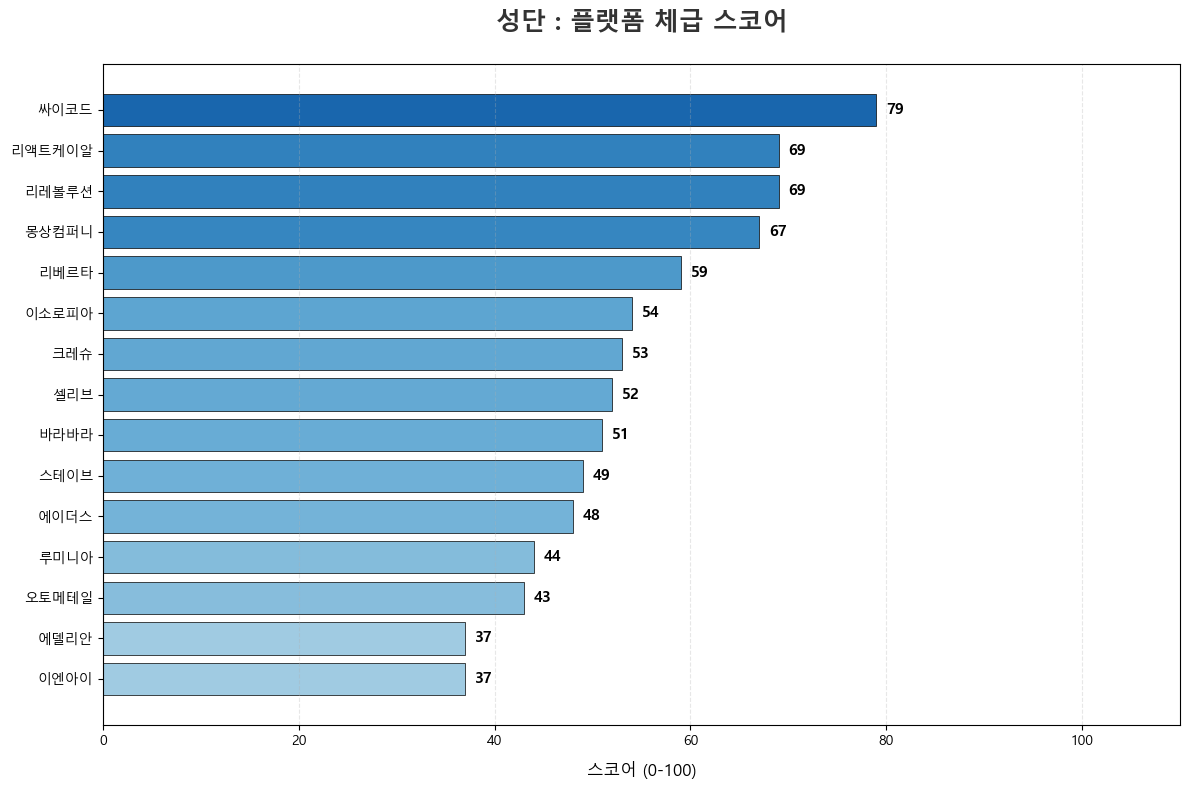

In [11]:
# [셀 1] 플랫폼체급 - 시원한 푸른색 그라데이션
draw_chart(final_plot_df, '플랫폼체급_점수', '성단 : 플랫폼 체급 스코어', 'Blues')

C:\Users\USER\AppData\Local\Temp\ipykernel_13192\530506873.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap(cmap_name)(df_plot[col_name] / 100)


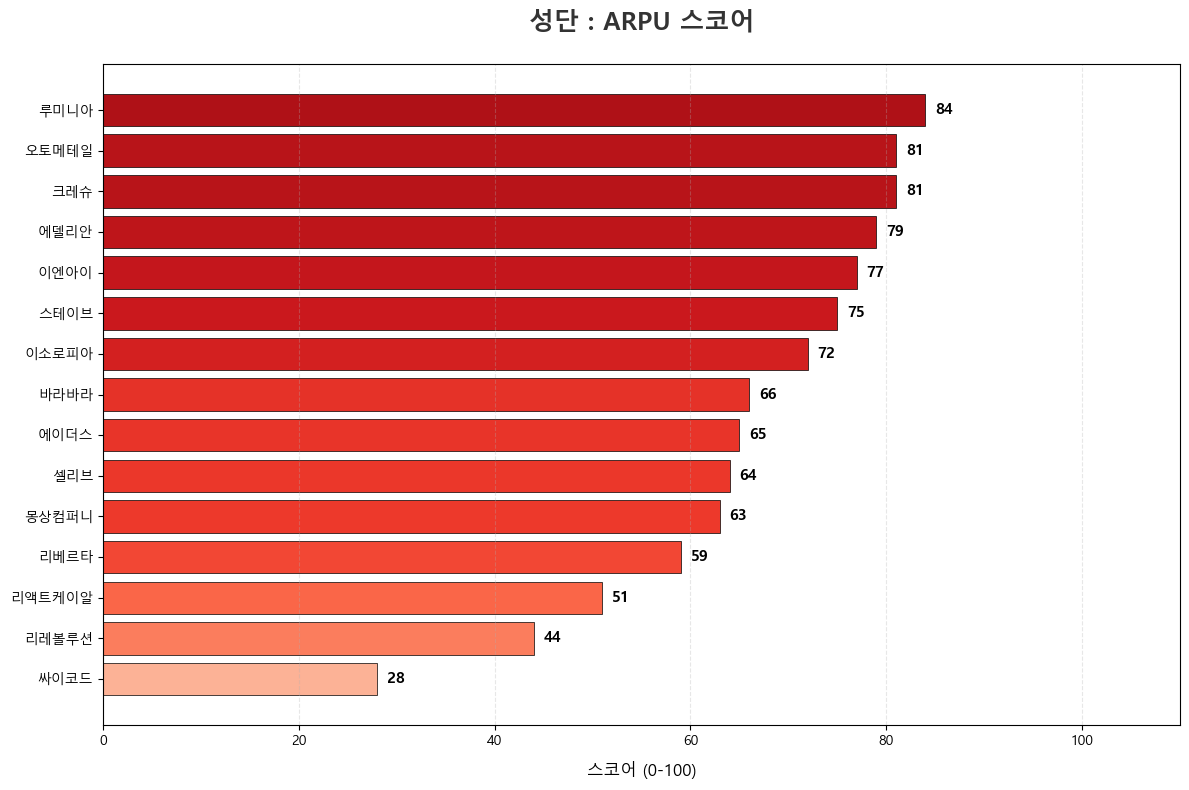

In [12]:
# [셀 2] ARPU - 열정적인 붉은색 그라데이션
draw_chart(final_plot_df, 'ARPU_점수', '성단 : ARPU 스코어', 'Reds')

C:\Users\USER\AppData\Local\Temp\ipykernel_13192\530506873.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap(cmap_name)(df_plot[col_name] / 100)


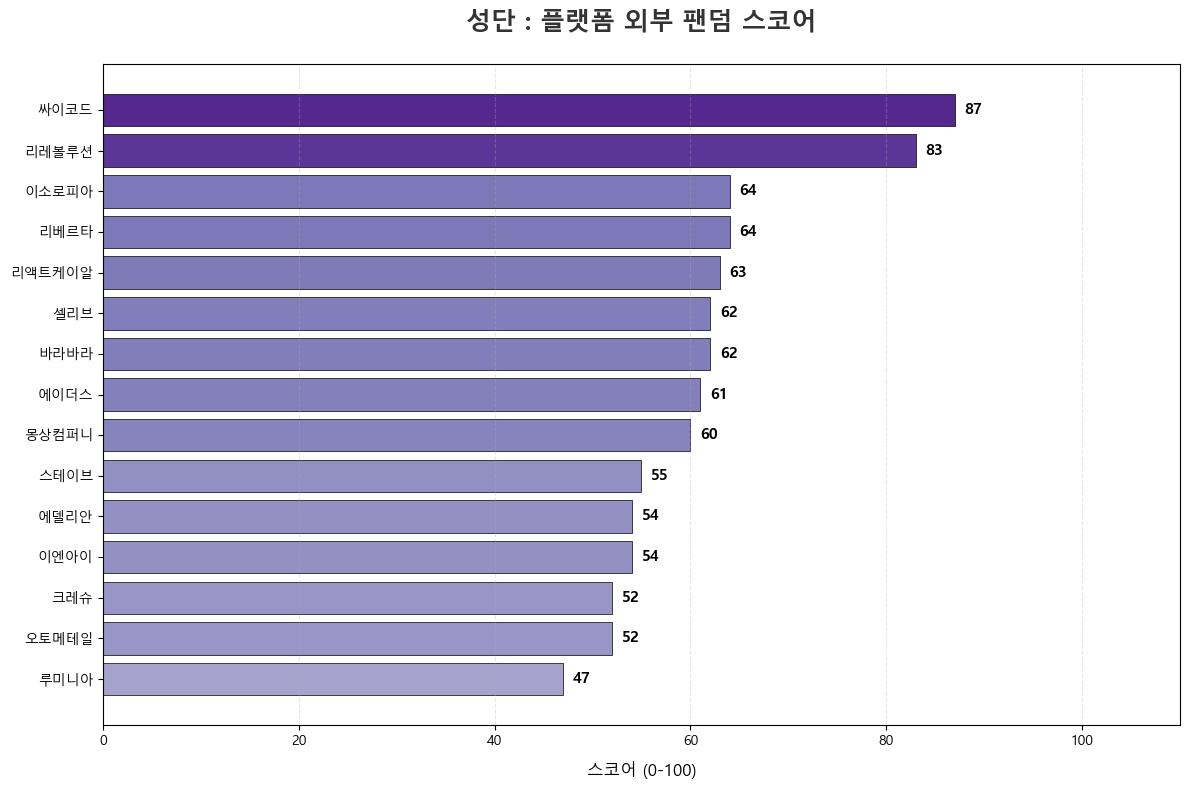

In [13]:
# [셀 3] 외부인기 - 신비로운 보라색 그라데이션
draw_chart(final_plot_df, '외부인기_점수', '성단 : 플랫폼 외부 팬덤 스코어', 'Purples')

C:\Users\USER\AppData\Local\Temp\ipykernel_13192\530506873.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap(cmap_name)(df_plot[col_name] / 100)


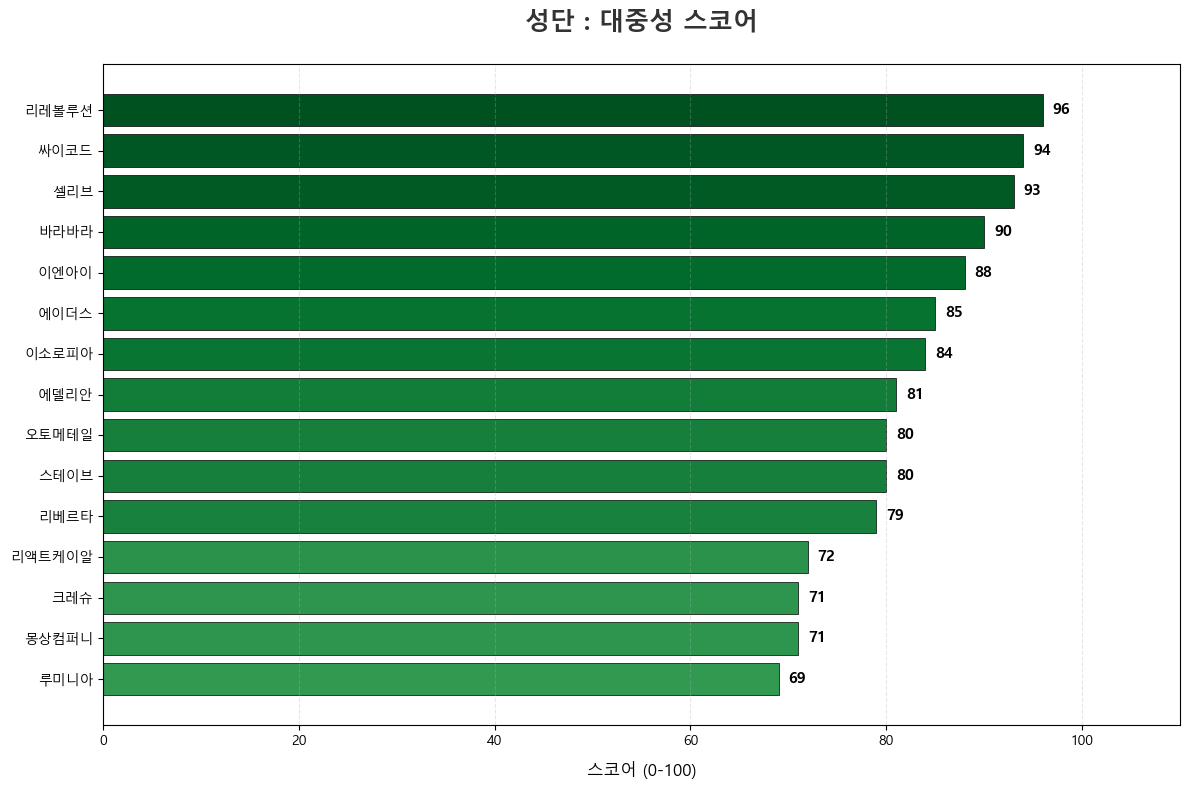

In [14]:
# [셀 4] 대중성 - 싱그러운 초록색 그라데이션
draw_chart(final_plot_df, '대중성_점수', '성단 : 대중성 스코어', 'Greens')

C:\Users\USER\AppData\Local\Temp\ipykernel_13192\530506873.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap(cmap_name)(df_plot[col_name] / 100)


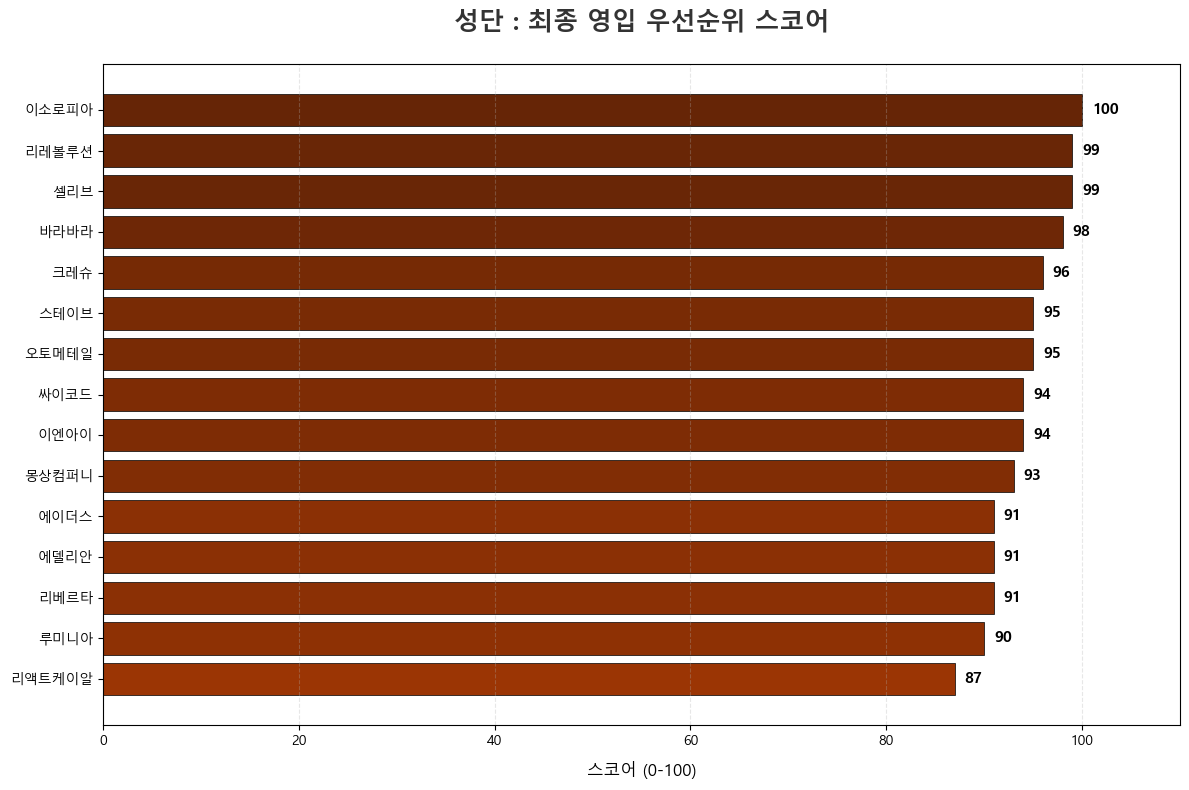

In [15]:

# [셀 5] 영입우선 - 영롱한 황금색 그라데이션
draw_chart(final_plot_df, '영입우선_점수', '성단 : 최종 영입 우선순위 스코어', 'YlOrBr')

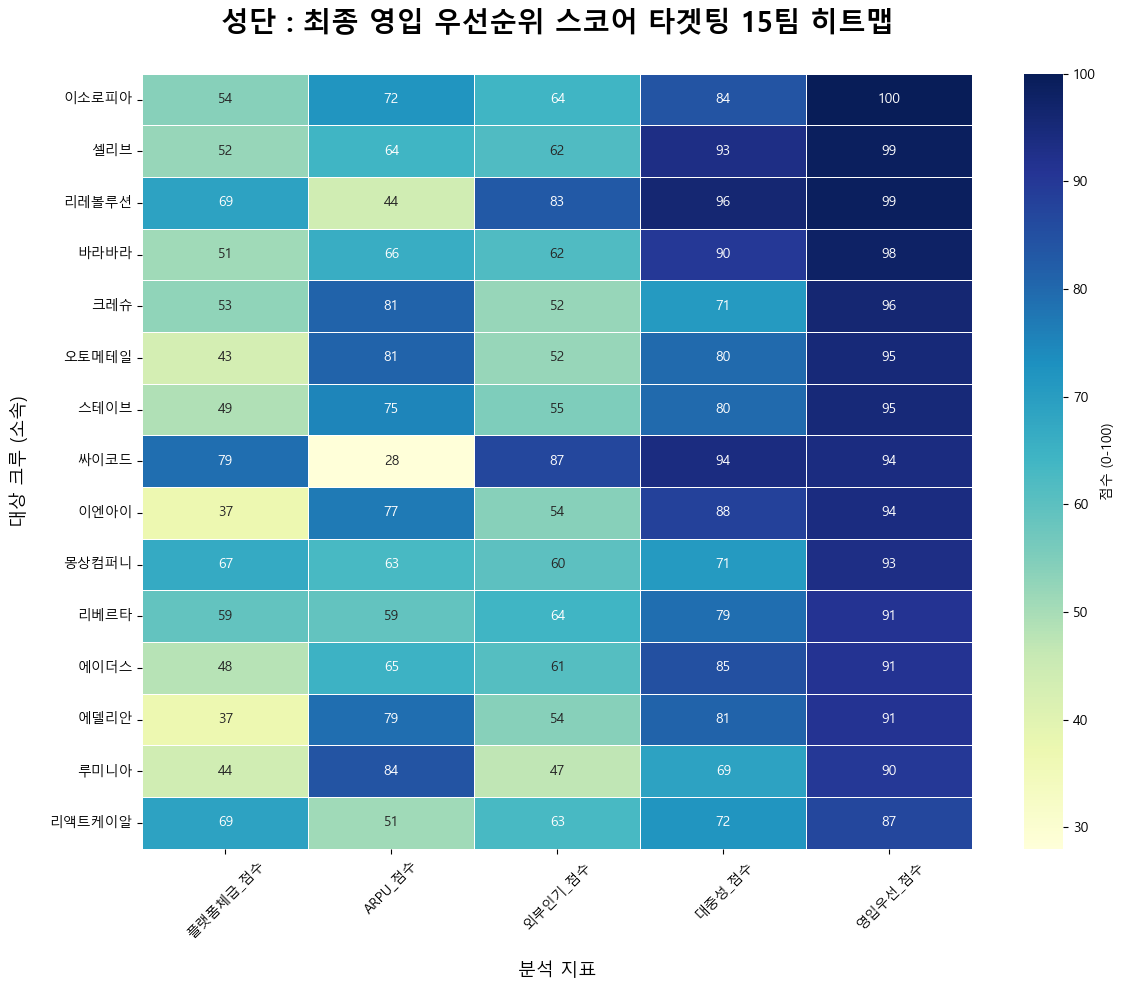

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

def draw_final_heatmap(df):
    # 1. 시각화할 컬럼 5개 선택 (선샌니가 정한 이름 그대로!)
    target_cols = ['플랫폼체급_점수', 'ARPU_점수', '외부인기_점수', '대중성_점수', '영입우선_점수']
    
    # 2. 팀 이름을 인덱스로 설정 (그래프 옆에 팀 이름이 나오게!)
    heatmap_data = df.set_index('소속')[target_cols]
    
    # 3. 영입우선_점수 순으로 정렬 (에이스가 맨 위로 오게!)
    heatmap_data = heatmap_data.sort_values(by='영입우선_점수', ascending=False)
    
    # 4. 히트맵 그리기
    plt.figure(figsize=(12, 10))
    sns.heatmap(heatmap_data, 
                annot=True,      # 숫자 표시
                fmt='d',         # 정수 형식
                cmap='YlGnBu',   # 노란색-초록색-파란색 그라데이션 (고급짐!)
                linewidths=0.5,  # 칸 사이 간격
                cbar_kws={'label': '점수 (0-100)'}) # 옆에 컬러바 설명
    
    # 제목 및 레이블 설정
    plt.title('성단 : 최종 영입 우선순위 스코어 타겟팅 15팀 히트맵', fontsize=20, pad=30, fontweight='bold')
    plt.xlabel('분석 지표', fontsize=13, labelpad=15)
    plt.ylabel('대상 크루 (소속)', fontsize=13, labelpad=15)
    
    plt.xticks(rotation=45) # 밑에 글자 살짝 돌려주기
    plt.tight_layout()
    plt.show()

# 실행 드가자~!
draw_final_heatmap(final_plot_df)

In [17]:
import pandas as pd
import numpy as np

# 1. 데이터 로드 및 기초 정제
df_main = pd.read_csv('final_softcone_for_team.csv', encoding='utf-8-sig')
df_main = df_main.dropna(subset=['소속'])

# 2. 블랙리스트 제외 (논외 및 불완전체)
black_list = ['왁타버스', '스코시즘', '하나비', '회사계정', '졸업']
df_main = df_main[~df_main['소속'].isin(black_list)]
df_main.fillna(0, inplace=True)

# 3. 그룹화 연산
agg_rules = {
    '스트리머명': 'count', '최고_팔로워': 'sum', '6분_최고채팅': 'max', '6분_평균채팅_최댓값': 'mean',
    '최고_시청자': 'max', '평균_시청자_최댓값': 'max', '뷰어십': 'sum', '도네이션': 'sum',
    'X_팔로워': 'sum', '유튜브_구독자': 'sum', '팬카페_가입자': 'max'
}
global_grouped_df = df_main.groupby('소속').agg(agg_rules).reset_index()
global_grouped_df.rename(columns={'스트리머명': '멤버수', '뷰어십': '합계_뷰어십', '도네이션': '합계_도네이션'}, inplace=True)

# 4. 안전한 스케일링 함수
def safe_minmax(series):
    if series.max() == series.min(): return pd.Series(0, index=series.index)
    return ((series - series.min()) / (series.max() - series.min())) * 100

# 5. 글로벌 기준 5대 지표 계산
# [ARPU]
grouped_df = global_grouped_df # 편의상 별칭
grouped_df['ARPU_점수'] = safe_minmax(np.log1p(grouped_df['합계_도네이션'] / (grouped_df['합계_뷰어십'] + 1)))

# [플랫폼체급]
int_cols = ['합계_뷰어십', '합계_도네이션', '최고_시청자', '평균_시청자_최댓값', '최고_팔로워', '6분_최고채팅']
grouped_df['체급_Z'] = 0
for col in int_cols:
    log_s = np.log1p(grouped_df[col])
    if log_s.std() > 0: grouped_df['체급_Z'] += (log_s - log_s.mean()) / log_s.std()
grouped_df['플랫폼체급_점수'] = safe_minmax(grouped_df['체급_Z'])

# [외부인기]
ext_cols = ['X_팔로워', '유튜브_구독자', '팬카페_가입자']
grouped_df['외부_Z'] = 0
for col in ext_cols:
    log_s = np.log1p(grouped_df[col])
    if log_s.std() > 0: grouped_df['외부_Z'] += (log_s - log_s.mean()) / log_s.std()
grouped_df['외부인기_점수'] = safe_minmax(grouped_df['외부_Z'])

# [대중성]
grouped_df['대중성_점수'] = safe_minmax(grouped_df['외부인기_점수'] / np.log1p(grouped_df['합계_뷰어십']).replace(0, 1))

# [영입우선]
grouped_df['영입우선_원본'] = grouped_df['플랫폼체급_점수'] + grouped_df['ARPU_점수'] + grouped_df['대중성_점수']
grouped_df['영입우선_점수'] = safe_minmax(grouped_df['영입우선_원본'])

# 소수점 정리
final_cols = ['플랫폼체급_점수', 'ARPU_점수', '외부인기_점수', '대중성_점수', '영입우선_점수']
grouped_df[final_cols] = grouped_df[final_cols].round(0).astype(int)

print("✅ 글로벌 기준 점수 계산 완료!")

✅ 글로벌 기준 점수 계산 완료!


C:\Users\USER\AppData\Local\Temp\ipykernel_13192\530506873.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap(cmap_name)(df_plot[col_name] / 100)


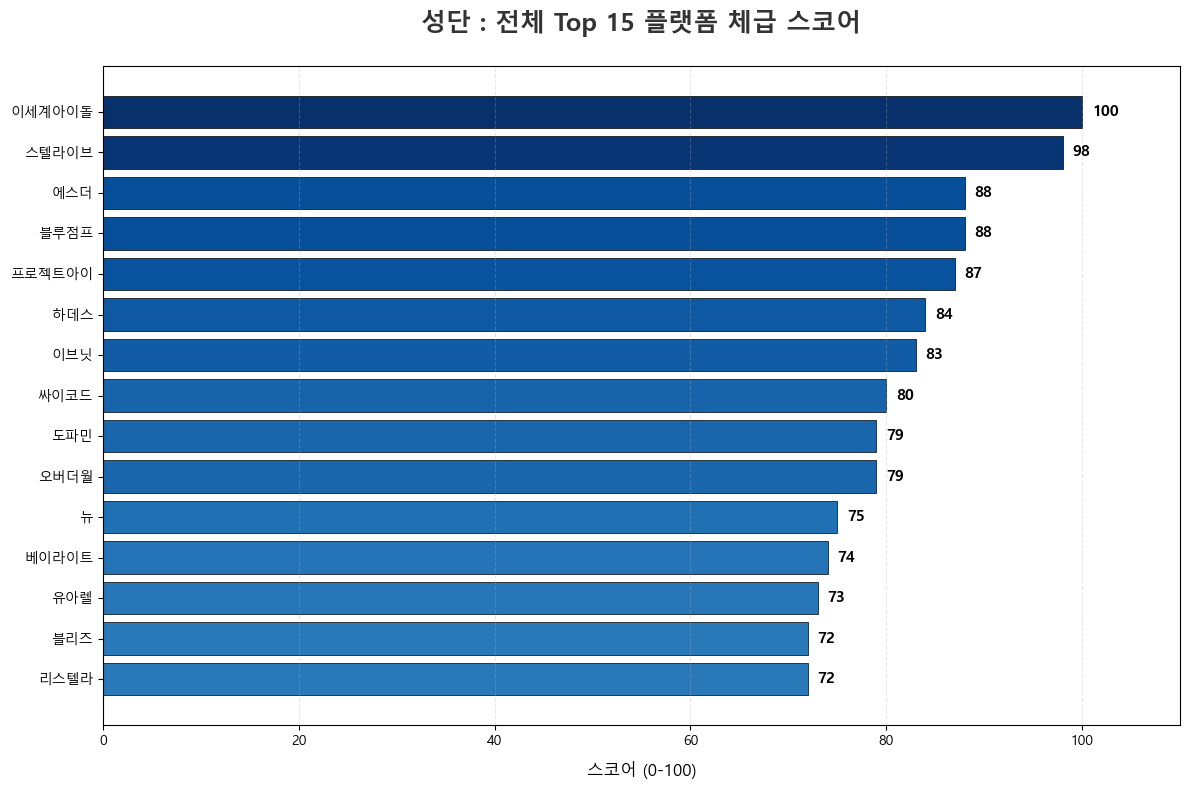

In [18]:
# 1. 플랫폼 체급 시각화
draw_chart(grouped_df.nlargest(15, '플랫폼체급_점수'), '플랫폼체급_점수', '성단 : 전체 Top 15 플랫폼 체급 스코어', 'Blues')

C:\Users\USER\AppData\Local\Temp\ipykernel_13192\530506873.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap(cmap_name)(df_plot[col_name] / 100)


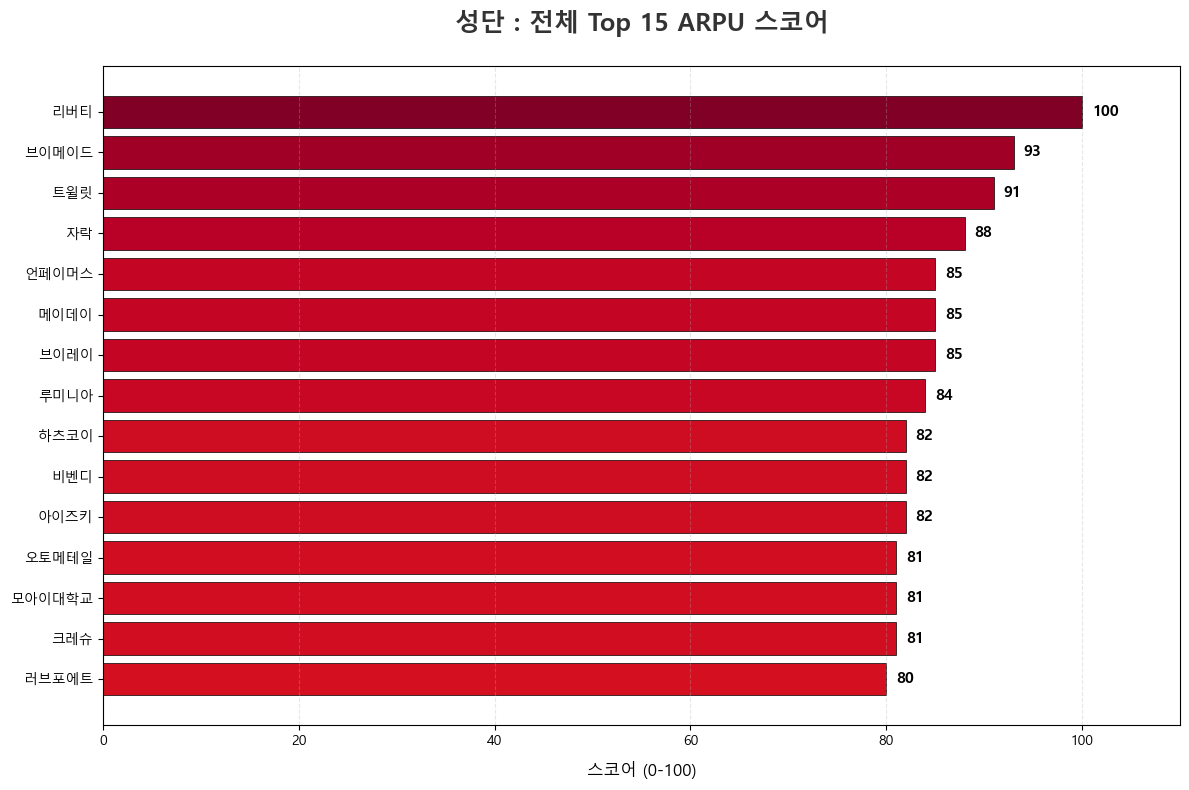

In [19]:
# 2. ARPU(팬덤 화력) 시각화
draw_chart(grouped_df.nlargest(15, 'ARPU_점수'), 'ARPU_점수', '성단 : 전체 Top 15 ARPU 스코어', 'YlOrRd')

C:\Users\USER\AppData\Local\Temp\ipykernel_13192\530506873.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap(cmap_name)(df_plot[col_name] / 100)


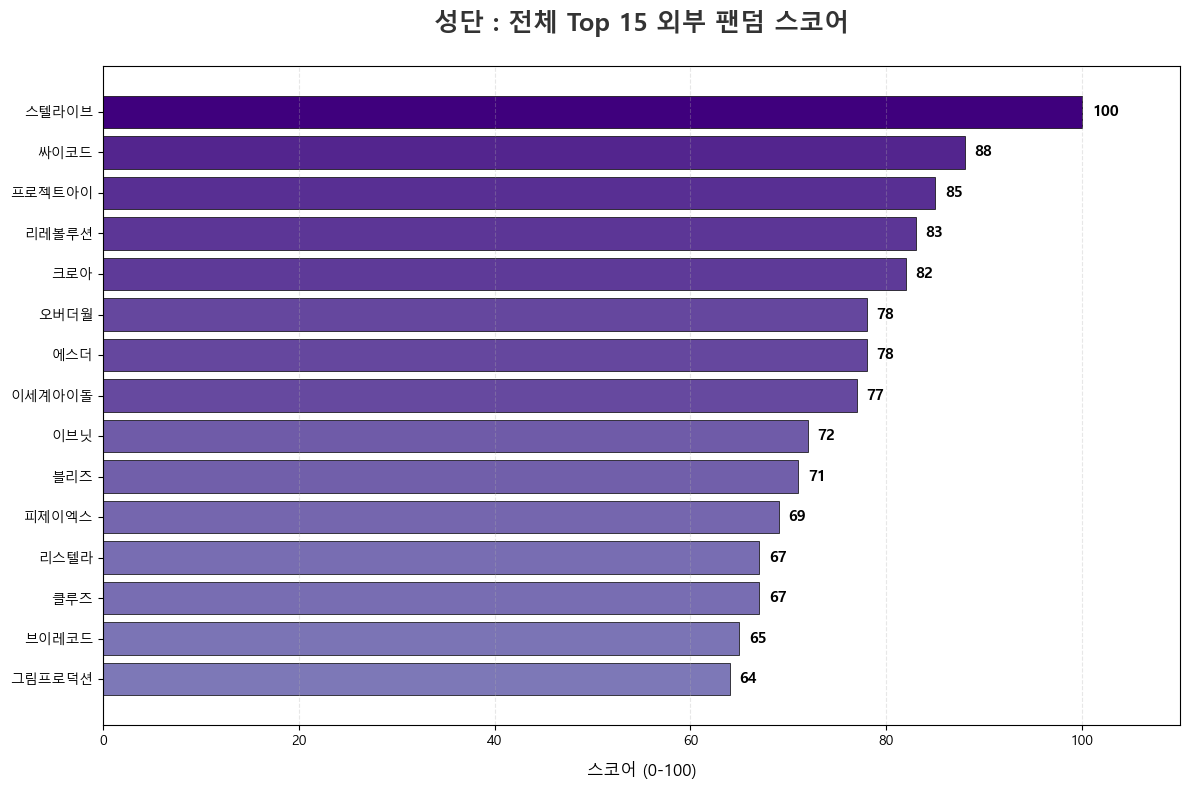

In [20]:
# 3. 외부 인기 시각화
draw_chart(grouped_df.nlargest(15, '외부인기_점수'), '외부인기_점수', '성단 : 전체 Top 15 외부 팬덤 스코어', 'Purples')

C:\Users\USER\AppData\Local\Temp\ipykernel_13192\530506873.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap(cmap_name)(df_plot[col_name] / 100)


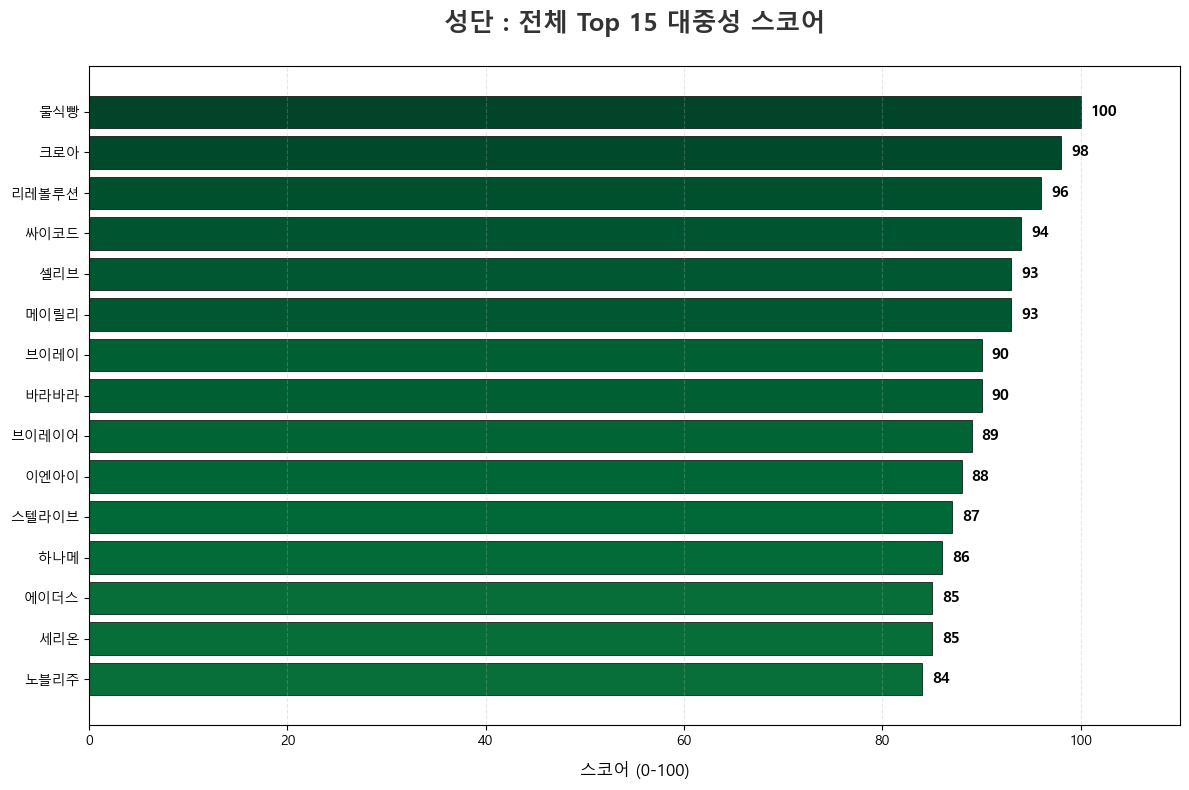

In [21]:
# 4. 대중성(가성비) 시각화
draw_chart(grouped_df.nlargest(15, '대중성_점수'), '대중성_점수', '성단 : 전체 Top 15 대중성 스코어', 'YlGn')

C:\Users\USER\AppData\Local\Temp\ipykernel_13192\530506873.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap(cmap_name)(df_plot[col_name] / 100)


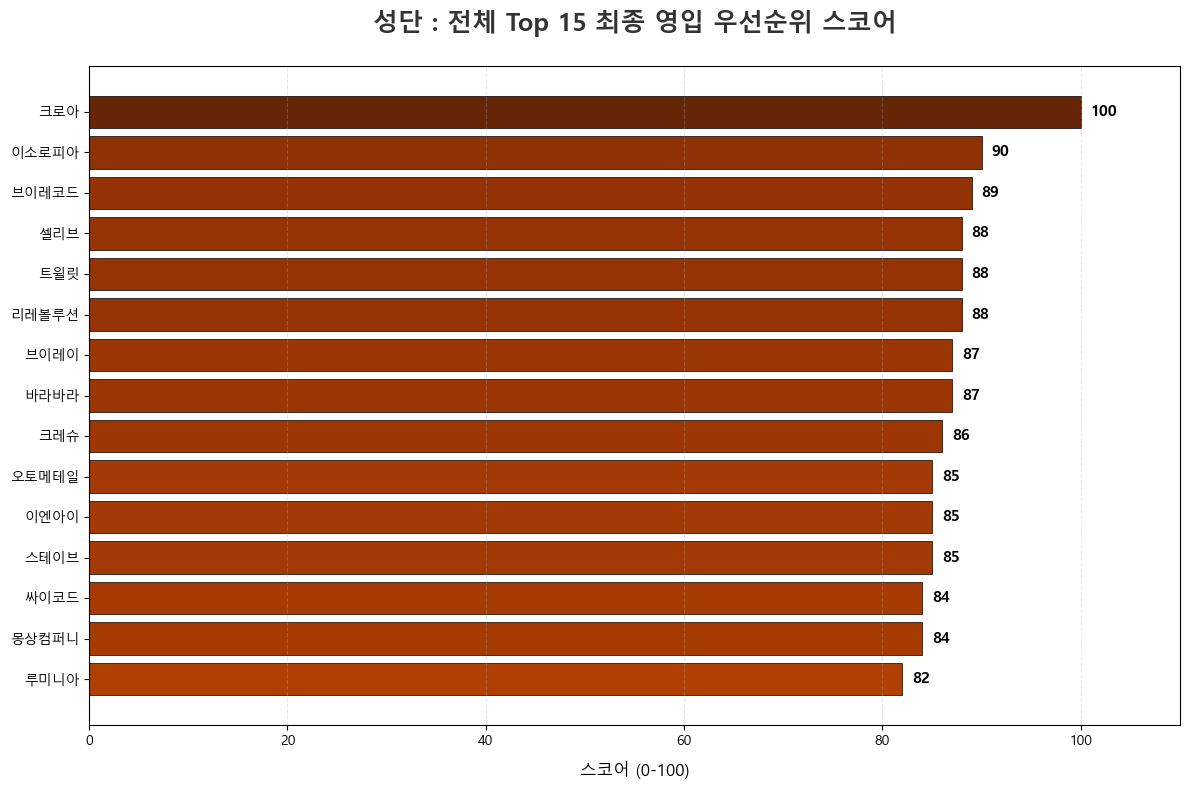

In [22]:
# 5. 최종 영입 우선순위 시각화
draw_chart(grouped_df.nlargest(15, '영입우선_점수'), '영입우선_점수', '성단 : 전체 Top 15 최종 영입 우선순위 스코어', 'YlOrBr')

In [23]:
# 1. 전체 팀 수 확인
total_teams_count = len(grouped_df)

# 2. 상위 1%에 해당하는 팀 수 계산 (최소 1팀 보장)
top_1_percent_limit = max(1, round(total_teams_count * 0.1))

# 3. 영입우선_점수 기준으로 상위 1% 명단 추출
top_1_percent_teams = grouped_df.nlargest(top_1_percent_limit, '영입우선_점수')

print(f"📊 분석 결과 리포트")
print(f"- 전체 후보군 규모: {total_teams_count}팀")
print(f"- 상위 1% 기준 팀 수: {top_1_percent_limit}팀")
print("-" * 30)
print(f"👑 상위 1% '신계' 크루 명단 👑")
print(top_1_percent_teams[['소속', '영입우선_점수', '합계_뷰어십']])

📊 분석 결과 리포트
- 전체 후보군 규모: 148팀
- 상위 1% 기준 팀 수: 15팀
------------------------------
👑 상위 1% '신계' 크루 명단 👑
        소속  영입우선_점수   합계_뷰어십
122    크로아      100   592857
112  이소로피아       90   189774
51   브이레코드       89   439737
23   리레볼루션       88   924754
69     셀리브       88    38574
129    트윌릿       88    17355
41    바라바라       87    56549
49    브이레이       87    12277
121    크레슈       86   136602
72    스테이브       85    56842
94   오토메테일       85    35465
113   이엔아이       85    18083
39   몽상컴퍼니       84   789706
78    싸이코드       84  2629047
22    루미니아       82    52288


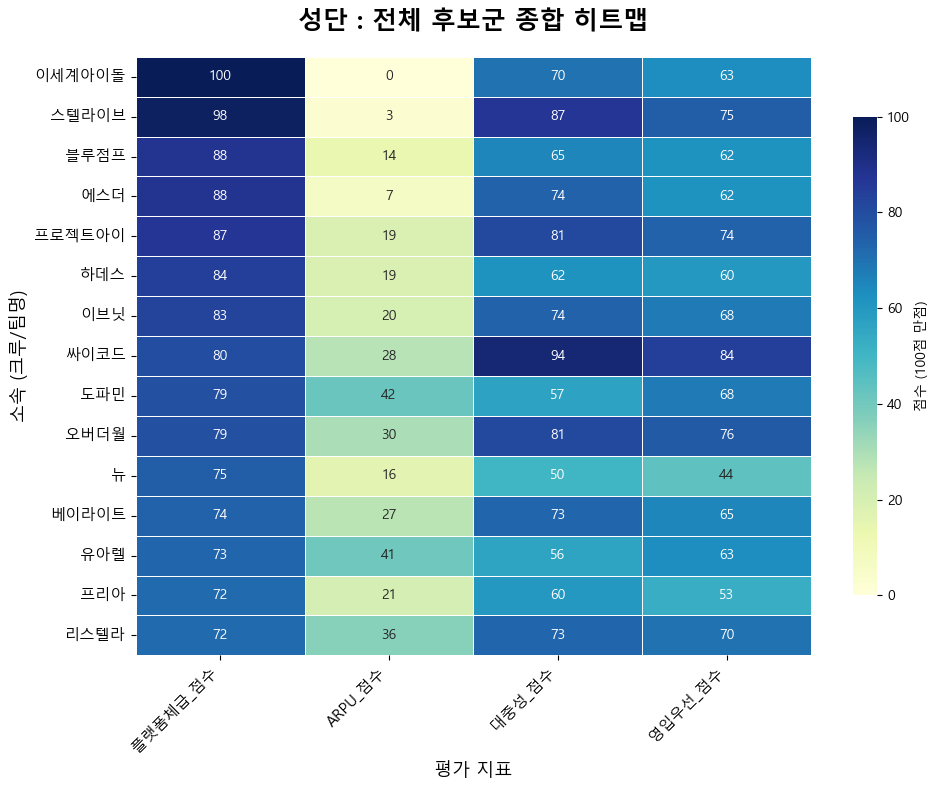

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 폰트 설정 (산사 선샌니 윈도우 환경이시면 맑은 고딕!)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 2. 시각화할 핵심 점수 컬럼들 (실제 데이터프레임 컬럼명에 딱 맞췄습니다!)
score_cols = ['플랫폼체급_점수', 'ARPU_점수', '대중성_점수', '영입우선_점수']

# 3. 영입우선_점수 기준으로 내림차순 정렬 후 상위 15팀만 딱 자르기!
df_top15 = grouped_df.sort_values(by='플랫폼체급_점수', ascending=False).head(15)

# 소속을 인덱스로 설정해서 히트맵 y축으로 만듭니다.
df_heatmap_top15 = df_top15.set_index('소속')[score_cols]

# 4. 히트맵 그리기
plt.figure(figsize=(10, 8)) 

sns.heatmap(
    df_heatmap_top15, 
    annot=True,       # 각 칸에 점수 숫자 표시
    fmt=".0f",        # 소수점 없이 깔끔하게!
    cmap="YlGnBu",    # 시원한 색상 테마 (YlGnBu가 제일 깔끔해요!)
    linewidths=.5,    # 칸마다 구분선 긋기
    cbar_kws={"shrink": .8, "label": "점수 (100점 만점)"} 
)

# 5. 그래프 꾸미기
plt.title("성단 : 전체 후보군 종합 히트맵", fontsize=18, pad=20, fontweight='bold')
plt.ylabel("소속 (크루/팀명)", fontsize=13)
plt.xlabel("평가 지표", fontsize=13)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)

# 여백 깔끔하게 정리 후 출력
plt.tight_layout()
plt.show()